In [331]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

This is to implement exercise 3.1.

The linear regression problem is: 

$$ y_k = \theta_1 + \theta_2 t_k + \epsilon_k $$

Where: 
$$\epsilon_k \sim N(0, \sigma^2)$$
$$\bf{\theta} = (\theta_1, \theta_2)^T $$
$$P(\bf{\theta}) = N(\theta | \bf{m_0}, \bf{P_0})$$
Measurements are: $D = \{(t_1, y_1), (t_2, y_2), ..., (t_T, y_T)\}$. 

Note: distinguish the meaning of "|" under different context: 
- in $P(\theta | y_{1:T})$, "|" means "conditional on";
- in $N(\theta | \bf{m_0}, \bf{P_0})$, "|" means "given the parameters of".

Also, even though $\theta$ is a vector, the density function $P(\theta)$ is a scalar which means the density at point $\theta$. 


Denoting $H_k = (1, t_k)$, then: $y_k = H_k \theta + \epsilon_k$, we get:
$$ P(y_k | \theta) =  N(y_k | H_k \theta, \sigma^2)$$
$$ P(y_{1:T} | \theta) = N(y_{1:T} | \bf{H} \theta, \sigma^2)$$

Where $\bf{H}$ is written as: 

\begin{equation}
\begin{pmatrix}
  H_1 \\
  H_2 \\
  \vdots \\
  H_T \\
\end{pmatrix}
\end{equation}

$$ P(\theta | y_{1:T}) = \frac{P(y_{1:T} | \theta) P(\theta)}{P(y_{1:T})} $$
$$ P(\theta | y_{1:T}) \propto P(\theta) \prod_{k=1}^{T} P(y_k | \theta) $$
$$ P(\theta | y_{1:T}) \propto N(\theta | \mathbf{m_0} , \mathbf{P_0}) \prod_{k=1}^{T} N(y_k | H_k \theta, \sigma^2)$$

$$ \propto exp\left((\theta- \mathbf{m_0})^T \mathbf{P_0^{-1}} (\theta- \mathbf{m_0}) \right)  exp\left( \frac{\sum_{k=1}^{T}(y_k - H_k \theta)^2}{\sigma^2}\right)$$

$$ = exp\left((\theta- \mathbf{m_0})^T \mathbf{P_0^{-1}} (\theta- \mathbf{m_0})  +  \frac{(Y-H \theta)^T  (Y-H \theta)}{\sigma^2}\right)$$

$$ = exp\left( \theta^T \left(P_0^{-1} + \frac{H^T H}{\sigma^2} \right)\theta  - 2\theta^T (P_0^{-1} \mathbf{m_0} + H^T Y) + m_0^T P_0^{-1} m_0 + \frac{Y^T H}{\sigma^2}  \right) $$

Hence:
$$m_T = \left(P_0^{-1} + \frac{H^T H}{\sigma^2} \right)^{-1} \left( P_0^{-1} \mathbf{m_0} + \frac{H^T Y}{\sigma^2} \right) $$
$$P_T = \left(P_0^{-1} + \frac{H^T H}{\sigma^2} \right)^{-1} $$


We can easily deduce the equation for recursive algorithm by just assuming $T=1$: 
$$m_k = \left(P_{k-1}^{-1} + \frac{H_k^T H_k}{\sigma^2} \right)^{-1} \left( P_{k-1}^{-1} \mathbf{m_{k-1}} + \frac{H_k^T Y_k}{\sigma^2}\right) $$
$$P_k = \left(P_{k-1}^{-1} + \frac{H_k^T H_k}{\sigma^2} \right)^{-1} $$


HOWEVER, we need to (again) watch out the dimensionality for $H_k$ and $y_k$: $H_k$ is a row vector, hence the dimension of $H_k^T H_k$ is $2\times 2$, same with $H^T H$. 

In [332]:
# Generate observations
n = 1000

t_list = [0.1*i for i in range(n)]

theta_1 = 5.
theta_2 = 3.
variance = 5.
epsilon = np.random.normal(0, variance, size=n)

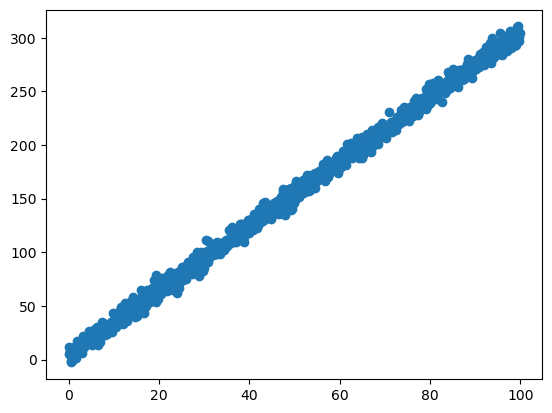

In [333]:
y_list = [theta_1  + theta_2 * t_list[i] + epsilon[i] for i in range(n)]
plt.scatter(t_list, y_list)
plt.show()

In [334]:
# Initialize the mean vector and covariance vector for theta 
m_0 = [0., 0.]
P_0 = [[1., 0.], [0., 1.]]

H = [[1, x] for x in t_list]
H = np.array(H)

In [354]:
# Difference between np.matmul and np.dot
a = np.random.rand(10, 3, 4)
b = np.random.rand(10, 4, 5)

np.dot(a, b).shape      # Wrong! -> (10, 3, 10, 4, 5) → unexpected


(10, 3, 10, 5)

In [355]:
np.matmul(a, b).shape   # Correct -> (10, 3, 5) → batch-wise matmul

(10, 3, 5)

In [335]:
# Batch estimation: we assume the standard deviation of the noise term is known
m_T =  np.matmul(np.linalg.inv((np.linalg.inv(P_0) + np.matmul(np.matrix.transpose(H), H)/(variance**2))),
                 (np.matmul(np.matrix.transpose(H), np.array(y_list))/(variance**2) + np.matmul(np.linalg.inv(P_0), m_0)))


P_T = np.linalg.inv((np.linalg.inv(P_0) + np.matmul(np.matrix.transpose(np.array(H)), np.array(H))/(variance**2)))
print(f'm_T={m_T}')
print(f'P_T={P_T}')

m_T=[4.4490722  3.00503816]
P_T=[[ 9.07833747e-02 -1.36242160e-03]
 [-1.36242160e-03  2.79576005e-05]]


In [336]:
# Batch estimation: we assume the standard deviation of the noise term is known
# replace matmul by .dot
m_T = np.linalg.inv(np.linalg.inv(P_0) + np.matrix.transpose(H).dot(H)/(variance**2)).dot(
    (np.matrix.transpose(H).dot(np.array(y_list))/(variance**2) + np.linalg.inv(P_0).dot(m_0)))


P_T = np.linalg.inv((np.linalg.inv(P_0) + np.matmul(np.matrix.transpose(np.array(H)), np.array(H))/(variance**2)))
print(f'm_T={m_T}')
print(f'p_T={P_T}')

m_T=[4.4490722  3.00503816]
p_T=[[ 9.07833747e-02 -1.36242160e-03]
 [-1.36242160e-03  2.79576005e-05]]


In [337]:
m_T

array([4.4490722 , 3.00503816])

In [338]:
P_T

array([[ 9.07833747e-02, -1.36242160e-03],
       [-1.36242160e-03,  2.79576005e-05]])

In [339]:
# recursive estimation 


m_k_prev = m_0
P_k_prev = np.array(P_0)

M = pd.DataFrame([m_0])

for k in range(1, n): 
    y_k = [y_list[k]]
    H_k = np.array([[1, t_list[k]]])

    S_k = H_k.dot(P_k_prev).dot(np.matrix.transpose(H_k)) + variance**2
    K_k = P_k_prev.dot(np.matrix.transpose(H_k))/S_k
                                                                                 
    m_k = m_k_prev + K_k.dot(y_k - H_k.dot(m_k_prev))
    P_k = P_k_prev - S_k*K_k.dot(np.matrix.transpose(K_k))

    M = pd.concat([M,pd.DataFrame([m_k])])
    m_k_prev = m_k
    P_k_prev = P_k

    
    
    

In [340]:
M['index'] = t_list
M.set_index('index', inplace=True)

<Axes: xlabel='index'>

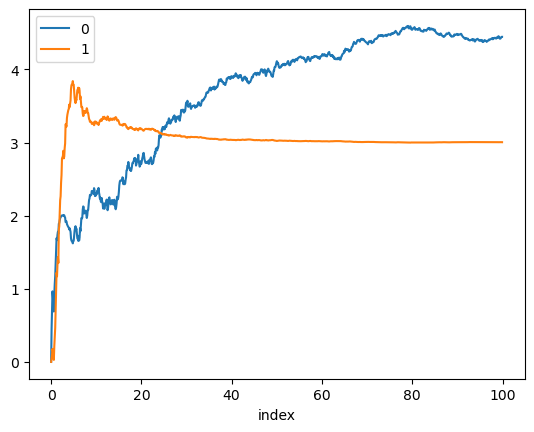

In [341]:
M.plot()

In [342]:
P_k

array([[ 9.11142410e-02, -1.36738704e-03],
       [-1.36738704e-03,  2.80321188e-05]])

In [343]:
# V2: original formulation
m_k_prev = m_0
P_k_prev = np.array(P_0)
 
for k in range(n): 
    y_k = [y_list[k]]
    H_k = np.array([[1, t_list[k]]])
                                                                          
    m_k = np.linalg.inv(np.linalg.inv(P_k_prev) + np.matrix.transpose(H_k).dot(H_k)/(variance**2)).dot(
        np.matrix.transpose(H_k).dot(y_k)/(variance**2) + np.linalg.inv(P_k_prev).dot(m_k_prev))
    P_k = np.linalg.inv(np.linalg.inv(P_k_prev) + np.matrix.transpose(H_k).dot(H_k)/(variance**2))

    m_k_prev = m_k
    P_k_prev = P_k

    

In [344]:
m_k

array([4.4490722 , 3.00503816])

In [345]:
P_k

array([[ 9.07833747e-02, -1.36242160e-03],
       [-1.36242160e-03,  2.79576005e-05]])

In [346]:
m_k

array([4.4490722 , 3.00503816])

In [347]:
k

999

# With drift: use recursive 

Formulation with drift:
$$ p(\theta_k | \theta_{k-1}) = N(\theta_k | \theta_{k-1}, Q)$$
$$ y_